In [2]:
!pip install -qU bertopic pandas nltk scikit-learn matplotlib xlwt 

In [3]:
# ============================================
# 0. CONFIGURATION & PARAMETERS
# ============================================

# --- Data paths ---
DATA_PATH = '/Users/Axel/Documents/github/wsm/data/pfas_in_food.csv'

# --- Column names in the CSV ---
TEXT_COLUMN = 'Abstract'
DATE_COLUMN = 'Date'

# --- Embedding model ---
SENTENCE_MODEL_NAME = 'all-MiniLM-L12-v2'

# --- UMAP parameters ---
UMAP_N_NEIGHBORS = 10
UMAP_N_COMPONENTS = 5
UMAP_MIN_DIST = 0.0
UMAP_METRIC = 'cosine'

# --- HDBSCAN parameters ---
HDBSCAN_MIN_CLUSTER_SIZE = 5
HDBSCAN_MIN_SAMPLES = 1
HDBSCAN_METRIC = 'euclidean'
HDBSCAN_CLUSTER_SELECTION_METHOD = 'leaf'
HDBSCAN_CLUSTER_SELECTION_EPSILON = 0.1

# --- Model saving ---
TOPIC_MODEL_SAVE_PATH = '/Users/Axel/Documents/github/wsm/data/bertopic_model_pfas_in_food'

## 1. Imports

In [4]:
# ============================================
# 1. IMPORTS
# ============================================

import re
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
from umap import UMAP
import hdbscan
from bertopic import BERTopic

import plotly.express as px


/Users/Axel/Documents/github/wsm/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load & Preprocess Data

In [5]:
# ============================================
# 2. LOAD & PREPROCESS DATA
# ============================================

# Load CSV
docs = pd.read_csv(DATA_PATH)

# Basic cleaning: require both text and date
docs = docs.dropna(subset=[TEXT_COLUMN, DATE_COLUMN])
docs = docs.reset_index(drop=True)
print(f"Loaded {len(docs)} rows after initial dropna().")

# Ensure text column is string
docs[TEXT_COLUMN] = docs[TEXT_COLUMN].astype(str)

# ---- Count before date parsing ----
count_before_date_parse = len(docs)

# Parse dates
docs[DATE_COLUMN] = pd.to_datetime(docs[DATE_COLUMN], errors='coerce')

# Drop rows with unparseable dates
docs = docs.dropna(subset=[DATE_COLUMN]).reset_index(drop=True)

# ---- Count after date parsing ----
count_after_date_parse = len(docs)

print(f"Rows before parsing dates:  {count_before_date_parse}")
print(f"Rows after date parsing:   {count_after_date_parse}")
print(f"Dropped due to bad dates:  {count_before_date_parse - count_after_date_parse}")

# Extract Year
docs["Year"] = docs[DATE_COLUMN].dt.year

# Publications per year
pubs_per_year = docs["Year"].value_counts().sort_index()
print("Publications per year:")
print(pubs_per_year)


Loaded 18179 rows after initial dropna().
Rows before parsing dates:  18179
Rows after date parsing:   18179
Dropped due to bad dates:  0
Publications per year:
Year
2003     159
2004    3337
2005    4372
2006    5019
2007    5106
2008     185
2019       1
Name: count, dtype: int64


In [6]:
# Count before filtering
count_before_year_filter = len(docs)

# Keep only publications between 2004 and 2007 (inclusive)
docs = docs[(docs["Year"] >= 2004) & (docs["Year"] <= 2006)].reset_index(drop=True)

# Count after filtering
count_after_year_filter = len(docs)

print(f"Rows before year filtering: {count_before_year_filter}")
print(f"Rows after year filtering:  {count_after_year_filter}")
print(f"Rows dropped:               {count_before_year_filter - count_after_year_filter}")

Rows before year filtering: 18179
Rows after year filtering:  12728
Rows dropped:               5451


In [7]:
# Prepare the abstracts as a list for BERTopic
text = docs[TEXT_COLUMN].astype(str).tolist()
len(text)

12728

## 3. Embeddings & Topic Modeling (UMAP + HDBSCAN + BERTopic)

In [8]:
# ============================================
# 3. LOAD PRE-TRAINED TOPIC MODEL
# ============================================

from bertopic import BERTopic

print("Loading pre-trained topic model...")
topic_model = BERTopic.load(TOPIC_MODEL_SAVE_PATH)

topic_info = topic_model.get_topic_info()
print(f"Number of topics (including outlier -1): {len(topic_info)}")
topic_info.head()

Loading pre-trained topic model...
Number of topics (including outlier -1): 655


,Topic,Count,Name,Representation,Representative_Docs
0,-1,905,-1_of_the_in_and,"[of, the, in, and, as, rats, to, that, was, with]",[This article gives an overview of the results...
1,0,307,0_asthma_allergy_allergic_allergens,"[asthma, allergy, allergic, allergens, allerge...",[Few studies have characterized the atopic pro...
2,1,143,1_vitamin_25ohd_calcium_bone,"[vitamin, 25ohd, calcium, bone, d3, sunlight, ...",[Vitamin D is essential for the maintenance of...
3,2,143,2_arctic_pcbs_pcb_contaminants,"[arctic, pcbs, pcb, contaminants, ocs, contami...",[The purpose of this study is to monitor and a...
4,3,133,3_don_mycotoxins_fusarium_mycotoxin,"[don, mycotoxins, fusarium, mycotoxin, deoxyni...",[The objective of the present study was to inv...


In [9]:
pattern = r"\bpfos\b"
mask = topic_info["Representation"].astype(str).str.contains(
    pattern, flags=re.IGNORECASE, regex=True
)

pfas_topics = topic_info[mask]
print(f"Number of topics containing 'pfos': {len(pfas_topics)}")

Number of topics containing 'pfos': 2


In [10]:
import pprint
pp = pprint.PrettyPrinter(width=120, compact=False)

for idx, row in pfas_topics.iterrows():
    print(f"\n=== Topic {row['Topic']} ===")
    print("Name:", row.get("Name", ""))
    print("Count:", row.get("Count", ""))
    print("Representation:")
    pp.pprint(row["Representation"])



=== Topic 97 ===
Name: 97_pfos_pfoa_pfcs_apfo
Count: 28
Representation:
['pfos',
 'pfoa',
 'pfcs',
 'apfo',
 'perfluorinated',
 'perfluorooctane',
 'linearbranched',
 'pfosa',
 'branched',
 'sulfonate']

=== Topic 420 ===
Name: 420_pfos_pfoskg_quail_mallards
Count: 8
Representation:
['pfos', 'pfoskg', 'quail', 'mallards', 'birds', 'mallard', 'laysan', 'bobwhite', 'geese', 'ld50']


## 4. Save Topic Model (optional)

In [11]:
# ============================================
# 4. LOAD TOPIC MODEL (COMPLETED)
# ============================================

print(f"Model successfully loaded from: {TOPIC_MODEL_SAVE_PATH}")

Model successfully loaded from: /Users/Axel/Documents/github/wsm/data/bertopic_model_pfas_in_food


In [12]:
# ============================================
# 5. BUILD DOC_INFO WITH DATES
# ============================================

# Make a clean copy of docs and ensure alignment
docs_model = docs.reset_index(drop=True).copy()
assert len(text) == len(docs_model), "len(text) must match len(docs)."

# Get document-level topic assignments from BERTopic
doc_info = topic_model.get_document_info(text).copy()

# Create a stable doc_id BEFORE any filtering
doc_info["doc_id"] = np.arange(len(doc_info))
docs_model["doc_id"] = np.arange(len(docs_model))

# Merge Date from docs_model into doc_info
doc_info = doc_info.merge(
    docs_model[["doc_id", DATE_COLUMN]],
    on="doc_id",
    how="left"
).rename(columns={DATE_COLUMN: "Date"})

# Drop outlier topic -1 AFTER alignment
doc_info = doc_info[doc_info["Topic"] != -1].copy()

# Ensure datetime
doc_info["Date"] = pd.to_datetime(doc_info["Date"], errors="coerce")

# Drop rows with missing dates (optional)
doc_info = doc_info.dropna(subset=["Date"]).copy()

# Convenience ID column
doc_info["ID"] = doc_info["doc_id"]

print(f"Documents available (no cutoff applied): {len(doc_info)}")
doc_info.head()


Documents available (no cutoff applied): 11823


,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document,doc_id,Date,ID
0,"Cassava (Manihot esculenta, Crantz) roots are ...",70,70_gm_genetically_gmos_cassava,"[gm, genetically, gmos, cassava, modified, tra...",[With the emergence of transgenic technologies...,gm - genetically - gmos - cassava - modified -...,0.129412,False,0,2006-12-15,0
1,"Mutagenic and/or carcinogenic substances, whic...",102,102_bap_adduct_pahs_adducts,"[bap, adduct, pahs, adducts, dna, poh, polycyc...",[We evaluated determinants of anti-benzo[a]pyr...,bap - adduct - pahs - adducts - dna - poh - po...,0.756701,False,1,2006-08-22,1
2,Microbiological examination of 200 meat produc...,82,82_aureus_staphylococcal_seb_enterotoxin,"[aureus, staphylococcal, seb, enterotoxin, iso...",[Staphylococcus aureus isolated from milk of c...,aureus - staphylococcal - seb - enterotoxin - ...,1.000000,False,2,2006-08-19,2
3,Strong evidence shows that mitochondrial dysfu...,152,152_als_bmaa_amyotrophic_12dab,"[als, bmaa, amyotrophic, 12dab, soccer, alspdc...",[The toxin beta-methylamino-l-alanine (BMAA) h...,als - bmaa - amyotrophic - 12dab - soccer - al...,1.000000,False,3,2006-08-16,3
4,The study was undertaken to assess the exposur...,38,38_fluoride_caries_dental_dentine,"[fluoride, caries, dental, dentine, enamel, we...",[Despite great improvements in the oral health...,fluoride - caries - dental - dentine - enamel ...,1.000000,False,4,2006-08-09,4


In [13]:
def list_contains_pfos(rep_list):
    if not isinstance(rep_list, list):
        return False
    return any("pfoa" in str(item).lower() for item in rep_list)

mask_pfos = doc_info["Representation"].apply(list_contains_pfos)
df_pfos = doc_info[mask_pfos].copy()

print("PFOS publications:", len(df_pfos))

PFOS publications: 28


In [14]:
df_pfos["Year"] = df_pfos["Date"].dt.year
pfos_per_year = df_pfos["Year"].value_counts().sort_index()
print(pfos_per_year)

Year
2004     5
2005     7
2006    16
Name: count, dtype: int64


In [15]:
df_pfos["YearMonth"] = df_pfos["Date"].dt.to_period("M")

In [16]:
pfos_per_month = df_pfos["YearMonth"].value_counts().sort_index()
all_months = pd.period_range(
    df_pfos["Date"].min().to_period("M"),
    df_pfos["Date"].max().to_period("M"),
    freq="M"
)

pfos_per_month_full = pfos_per_month.reindex(all_months, fill_value=0)
print(pfos_per_month_full)


2004-03    2
2004-04    0
2004-05    0
2004-06    0
2004-07    0
2004-08    1
2004-09    0
2004-10    0
2004-11    1
2004-12    1
2005-01    1
2005-02    0
2005-03    0
2005-04    1
2005-05    1
2005-06    0
2005-07    0
2005-08    0
2005-09    1
2005-10    3
2005-11    0
2005-12    0
2006-01    4
2006-02    0
2006-03    1
2006-04    0
2006-05    0
2006-06    1
2006-07    4
2006-08    1
2006-09    1
2006-10    3
2006-11    0
2006-12    1
Freq: M, Name: count, dtype: int64


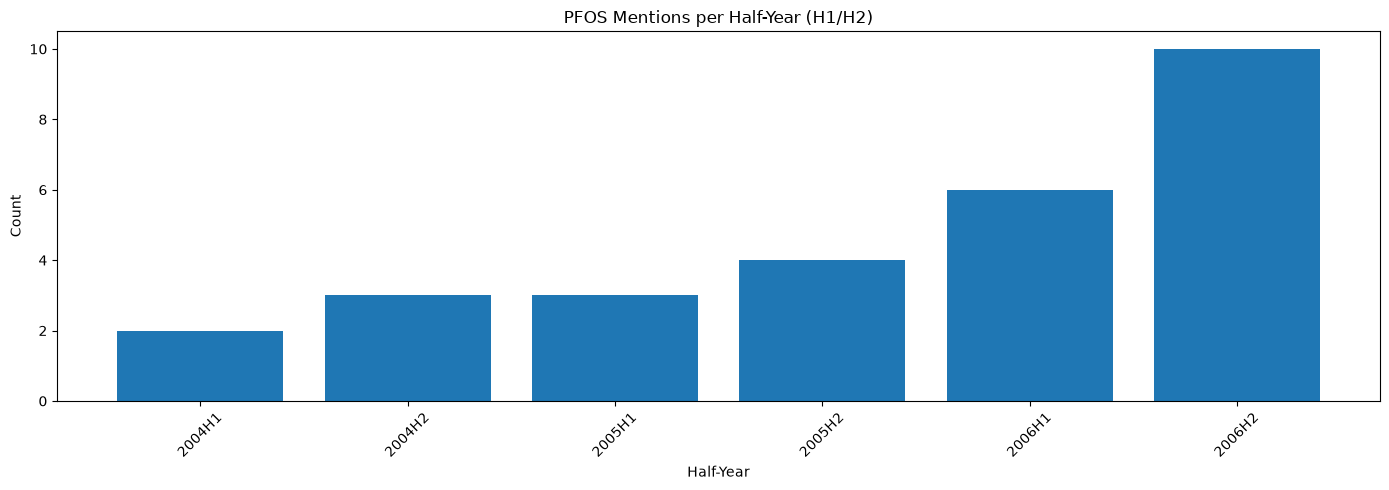

In [17]:
import matplotlib.pyplot as plt

df_pfos["Half"] = df_pfos["Date"].dt.month.map(lambda m: 1 if m <= 6 else 2)
df_pfos["HalfYear"] = df_pfos["Date"].dt.year.astype(str) + "H" + df_pfos["Half"].astype(str)

pfos_6m = df_pfos["HalfYear"].value_counts().sort_index()

plt.figure(figsize=(14,5))
plt.bar(pfos_6m.index, pfos_6m.values)
plt.title("PFOS Mentions per Half-Year (H1/H2)")
plt.xlabel("Half-Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. Topic Metadata (`Name` & `Representation`)

In [18]:
# ============================================
# 6. TOPIC METADATA (Name & Representation)
# ============================================

# Ensure we have a Name column for each document's topic
if 'Name' not in doc_info.columns or doc_info['Name'].isna().all():
    labels = topic_model.generate_topic_labels()
    doc_info['Name'] = doc_info['Topic'].map(labels)

# Get topic_info and ensure Representation is present
try:
    topic_info = topic_model.get_topic_info()
    if 'Representation' not in topic_info.columns:
        topic_info['Representation'] = topic_info['Name']
except Exception:
    topic_info = pd.DataFrame({'Name': doc_info['Name'].unique()})
    topic_info['Count'] = (
        doc_info['Name']
        .value_counts()
        .reindex(topic_info['Name'])
        .fillna(0)
        .astype(int)
    )
    topic_info['Representation'] = topic_info['Name']

topic_info.head()


,Topic,Count,Name,Representation,Representative_Docs
0,-1,905,-1_of_the_in_and,"[of, the, in, and, as, rats, to, that, was, with]",[This article gives an overview of the results...
1,0,307,0_asthma_allergy_allergic_allergens,"[asthma, allergy, allergic, allergens, allerge...",[Few studies have characterized the atopic pro...
2,1,143,1_vitamin_25ohd_calcium_bone,"[vitamin, 25ohd, calcium, bone, d3, sunlight, ...",[Vitamin D is essential for the maintenance of...
3,2,143,2_arctic_pcbs_pcb_contaminants,"[arctic, pcbs, pcb, contaminants, ocs, contami...",[The purpose of this study is to monitor and a...
4,3,133,3_don_mycotoxins_fusarium_mycotoxin,"[don, mycotoxins, fusarium, mycotoxin, deoxyni...",[The objective of the present study was to inv...


## 7. Topic Share by Time Bucket (M/W/D)

In [19]:
# ============================================
# 7. TOPIC SHARE BY HALF-YEAR BUCKET (H1/H2)
# ============================================
#
# We aggregate documents into TRUE half-year buckets:
#   - H1: January–June
#   - H2: July–December
# and compute per-topic shares within each half-year.
#
# This reduces monthly noise and makes sustained emerging patterns
# (such as PFOS 2004–2006) stand out more clearly.

import numpy as np
import pandas as pd

def shares_by_halfyear(df: pd.DataFrame) -> pd.DataFrame:
    tmp = df.copy()

    # Define clean, non-overlapping half-year labels like "2004H1", "2004H2"
    tmp["HalfYear"] = (
        tmp["Date"].dt.year.astype(str)
        + "H"
        + np.where(tmp["Date"].dt.month <= 6, "1", "2")
    )

    # Count documents per (HalfYear, Topic Name)
    counts = pd.pivot_table(
        tmp,
        index="HalfYear",
        columns="Name",
        aggfunc="size",
        fill_value=0,
    )

    # Convert to per-half-year topic shares
    row_sums = counts.sum(axis=1).replace(0, 1)
    shares = counts.div(row_sums, axis=0)
    return shares

# Compute half-year topic shares for the entire corpus
shares = shares_by_halfyear(doc_info)
chosen = "H2"   # custom label indicating half-year buckets

print("Chosen time bucket: HalfYear (H1/H2)")
display(shares.head())


Chosen time bucket: HalfYear (H1/H2)


Name,0_asthma_allergy_allergic_allergens,100_cq_antimalarial_plasmodium_falciparum,101_bcaa_gh_msud_iss,102_bap_adduct_pahs_adducts,103_epilepsy_ketogenic_seizures_antiepileptic,104_cryptosporidium_microsporidia_oocysts_parasites,105_ra_arthritis_mri_inflammation,106_pbdes_pbde_diphenyl_bde,107_fas_trastuzumab_her2neu_breast,108_semicarbazide_nitrofuran_nitrofurazone_nitrofurans,...,91_se_selenium_sturgeon_microgg,92_rumen_ruminal_cla_acidosis,93_pg_pcddfs_dioxins_teq,94_azteca_postexposure_hyalella_copepods,95_pgp_transport_intestinal_bap,96_prostate_pca_mkp5_cancer,97_pfos_pfoa_pfcs_apfo,98_parabens_estrogenic_estrogens_calux,99_sgk1_ang_highsalt_epo,9_deet_larvae_larval_insecticides
HalfYear,,,,,,,,,,,,,,,,,,,,,
2004H1,0.029265,0.003569,0.003569,0.002855,0.002855,0.002141,0.002141,0.002141,0.001428,0.001428,...,0.002141,0.000714,0.002855,0.002855,0.000714,0.002855,0.001428,0.002141,0.000714,0.009279
2004H2,0.025347,0.003018,0.000604,0.002414,0.002414,0.003621,0.001811,0.002414,0.001811,0.000604,...,0.002414,0.004225,0.001207,0.002414,0.004225,0.003018,0.001811,0.003621,0.004225,0.013881
2005H1,0.031821,0.001043,0.001565,0.001043,0.002087,0.003130,0.004173,0.003652,0.003652,0.002608,...,0.005738,0.003130,0.003652,0.002087,0.002087,0.001043,0.001565,0.001565,0.001565,0.008346
2005H2,0.022357,0.002795,0.002329,0.003260,0.001863,0.001863,0.000932,0.001397,0.002329,0.002329,...,0.000466,0.001397,0.002795,0.002795,0.000932,0.003260,0.001863,0.001863,0.000000,0.008384
2006H1,0.023840,0.001703,0.003406,0.001703,0.003406,0.001703,0.003406,0.002129,0.002980,0.002129,...,0.002554,0.001703,0.000851,0.001277,0.003831,0.001703,0.002554,0.001703,0.005109,0.009366


## 8. Compute Recency Score & Recency + Magnitude Score

In [20]:
# ============================================
# 8. RECENCY-ONLY + RECENCY+MAGNITUDE SCORES
# ============================================

# We assume `shares` is a DataFrame with:
#   - index: time buckets (e.g. months)
#   - columns: topic names (matching topic_info["Name"])
# and `chosen` is the frequency string ('M', 'W', or 'D').

# --- Time decay for recency scoring ---
HALF_LIFE = 1.0                # in units of the chosen bucket (M/W/D)

# --- Magnitude (jump) weighting ---
MAG_ALPHA = 4.0                # strength of magnitude contribution (tune up to boost PFOS)
RECENT_WINDOW = 2              # number of most recent buckets to treat as "recent history"

import numpy as np
import pandas as pd

if shares is None or chosen is None:
    raise RuntimeError("Time-bucketed topic shares not available. Run the previous cell that computes `shares` and `chosen`.")

# Ensure temporal ordering
shares_sorted = shares.sort_index()
n_buckets = len(shares_sorted)

# -------------------------------------------------
# 1) RECENCY SCORE (EXPONENTIAL TIME DECAY)
# -------------------------------------------------
# Newer buckets get higher weight; HALF_LIFE controls how fast weight decays.

# Age 0 for the most recent bucket, 1 for previous, etc.
ages = np.arange(n_buckets - 1, -1, -1, dtype=float)
# Exponential decay: weight halves every HALF_LIFE buckets
w = 0.5 ** (ages / max(HALF_LIFE, 1e-6))
w = w / w.sum()

# Weighted average over time for each topic
recency_score = (shares_sorted.mul(w, axis=0)).sum(axis=0)

# -------------------------------------------------
# 2) MAGNITUDE TERM: RECENT vs HISTORICAL MEAN
# -------------------------------------------------
# Instead of just (last - previous), we compare the recent mean to the
# mean over all earlier buckets. This rewards sustained increases (like PFOS 2004–2006),
# not only single one-step shocks.

if n_buckets > RECENT_WINDOW:
    recent_mean = shares_sorted.tail(RECENT_WINDOW).mean(axis=0)
    past_mean = shares_sorted.iloc[:-RECENT_WINDOW].mean(axis=0)
else:
    # Fallbacks for very short histories
    recent_mean = shares_sorted.tail(1).iloc[0]
    if n_buckets > 1:
        past_mean = shares_sorted.iloc[:-1].mean(axis=0)
    else:
        past_mean = pd.Series(0.0, index=shares_sorted.columns)

jump_raw = recent_mean - past_mean
jump_strength = jump_raw  # can be further transformed if needed

# -------------------------------------------------
# 3) LIFETIME PENALTY
# -------------------------------------------------
# Penalize topics that have been active in many buckets (long-established topics),
# and relatively boost topics that ramp up more recently (emerging patterns).

lifetime = (shares_sorted > 0).sum(axis=0).astype(float)
penalty = 1.0 / np.log1p(lifetime)
penalty.replace([np.inf, -np.inf], 0.0, inplace=True)
penalty = penalty.fillna(0.0)

# -------------------------------------------------
# 4) FINAL RECENCY + MAGNITUDE SCORE
# -------------------------------------------------

recency_jump_score = (recency_score + MAG_ALPHA * jump_strength) * penalty

# Align indices (safety)
recency_score = recency_score.sort_index()
jump_strength = jump_strength.reindex(recency_score.index).fillna(0.0)
recency_jump_score = recency_jump_score.reindex(recency_score.index).fillna(0.0)

print(
    f"Computed recency_score (half-life={HALF_LIFE}, freq='{chosen}'), "
    f"magnitude term (recent vs historical mean, window={RECENT_WINDOW}), "
    "and combined recency_jump_score with lifetime penalty."
)

display(
    pd.DataFrame({
        "recency_score": recency_score,
        "jump_strength": jump_strength,
        "recency_jump_score": recency_jump_score,
    }).head()
)


Computed recency_score (half-life=1.0, freq='H2'), magnitude term (recent vs historical mean, window=2), and combined recency_jump_score with lifetime penalty.


,recency_score,jump_strength,recency_jump_score
Name,,,
0_asthma_allergy_allergic_allergens,0.024925,-0.002735,0.007187
100_cq_antimalarial_plasmodium_falciparum,0.002302,-0.000479,0.000198
101_bcaa_gh_msud_iss,0.002416,0.000749,0.002782
102_bap_adduct_pahs_adducts,0.002330,-0.000266,0.000650
103_epilepsy_ketogenic_seizures_antiepileptic,0.002004,0.000036,0.001104


## 9. Build Plotting DataFrame

In [21]:
# ============================================
# 9. BUILD PLOTTING DATAFRAMES (RECENCY VS RECENCY+JUMP)
# ============================================

# Base topic meta
topic_meta = topic_info[["Name", "Count", "Representation"]].copy()

# --- Recency + jump df_plot_jump ---
df_plot_jump = (
    recency_jump_score
    .rename("recency_jump_score")     # 👈 give the Series a proper name
    .reset_index()
    .rename(columns={"index": "Name"})
)

df_extra = pd.DataFrame({
    "Name": recency_score.index,
    "recency_score": recency_score.values,
    "jump_strength": jump_strength.values,
})

df_plot_jump = df_plot_jump.merge(df_extra, on="Name", how="left")
df_plot_jump = df_plot_jump.merge(topic_meta, on="Name", how="left")

if ("Count" not in df_plot_jump.columns) or df_plot_jump["Count"].isna().all():
    counts = (
        doc_info["Name"]
        .value_counts()
        .reindex(df_plot_jump["Name"])
        .fillna(0)
        .astype(int)
    )
    df_plot_jump["Count"] = counts.values

display(df_plot_jump.head())

,Name,recency_jump_score,recency_score,jump_strength,Count,Representation
0,0_asthma_allergy_allergic_allergens,0.007187,0.024925,-0.002735,307,"[asthma, allergy, allergic, allergens, allerge..."
1,100_cq_antimalarial_plasmodium_falciparum,0.000198,0.002302,-0.000479,28,"[cq, antimalarial, plasmodium, falciparum, vac..."
2,101_bcaa_gh_msud_iss,0.002782,0.002416,0.000749,27,"[bcaa, gh, msud, iss, glutaric, gcdh, deficien..."
3,102_bap_adduct_pahs_adducts,0.000650,0.002330,-0.000266,27,"[bap, adduct, pahs, adducts, dna, poh, polycyc..."
4,103_epilepsy_ketogenic_seizures_antiepileptic,0.001104,0.002004,0.000036,27,"[epilepsy, ketogenic, seizures, antiepileptic,..."


## 10. Visualize Topics & Highlight PFOS

In [22]:
import plotly.graph_objects as go
import re

# --- Boolean mask: Representation contains the token "pfos" ---
mask_pfos = df_plot_jump["Representation"].apply(
    lambda lst: any(re.fullmatch(r"pfoa", str(x).lower()) for x in lst)
)

df_main = df_plot_jump[~mask_pfos]
df_highlight = df_plot_jump[mask_pfos]

fig = go.Figure()

# --- Base layer: all topics ---
fig.add_trace(
    go.Scatter(
        x=df_main["Count"],
        y=df_main["recency_jump_score"],
        mode="markers",
        marker=dict(size=8, opacity=0.7),
        text=df_main["Name"],
        hovertext=df_main["Representation"].astype(str),
        name="All topics",
    )
)

# --- Highlighted: topics containing the exact token "pfos" ---
fig.add_trace(
    go.Scatter(
        x=df_highlight["Count"],
        y=df_highlight["recency_jump_score"],
        mode="markers",
        marker=dict(
            size=14,
            color="red",
            line=dict(width=2, color="black")
        ),
        text=df_highlight["Name"],
        hovertext=df_highlight["Representation"].astype(str),
        name="PFOS-related topic",
    )
)

# Axis + layout
fig.update_xaxes(title_text="Count")
fig.update_yaxes(title_text="recency_magnitude_score")

fig.update_layout(
    title="Weak-signals: recency + magnitude of topics (highlighting PFOS topic)"
)

fig.show()


## 11. Top-k Weak Signals

In [23]:
# --- Weak-signal ranking parameters ---
TOP_K_WEAK = 30                  # target number of weak signals to present
WEAK_MIN_COUNT = 10              # minimum topic Count to consider
WEAK_MIN_UPPER_COUNT = 30        # absolute upper bound for Count (kept!)
SCORE_MIN_THRESHOLD = 0.005       # minimum recency_jump_score to be considered


# ============================================
# 11. TOP-K WEAK SIGNALS (RECENCY+MAGNITUDE)
# ============================================

def rank_weak_signals(df_plot, score_col, label):
    df_rank = df_plot.copy()

    # Ensure valid numeric values
    df_rank = df_rank.dropna(subset=[score_col, "Count"]).copy()
    df_rank = df_rank.rename(columns={score_col: "score"})

    # -------------------------------------------------
    # 1) Apply Count bounds + score threshold
    # -------------------------------------------------

    lower = WEAK_MIN_COUNT
    upper = WEAK_MIN_UPPER_COUNT   # <-- KEEP absolute upper bound

    print(f"[{label}] Weak-signal Count range (absolute): [{lower}, {upper}]")
    print(f"[{label}] Score threshold: score >= {SCORE_MIN_THRESHOLD}")

    candidates = df_rank[
        (df_rank["Count"] >= lower) &
        (df_rank["Count"] <= upper) &
        (df_rank["score"] >= SCORE_MIN_THRESHOLD)
    ].copy()

    if candidates.empty:
        print(f"[{label}] No weak-signal candidates after applying Count+score filters.")
        return pd.DataFrame()

    # -------------------------------------------------
    # 2) Compute weak_signal_score = combined score + inverted Count
    # -------------------------------------------------

    # Inverted Count (low count = good)
    c_min, c_max = candidates["Count"].min(), candidates["Count"].max()
    if c_max > c_min:
        count_norm = 1.0 - (candidates["Count"] - c_min) / (c_max - c_min)
    else:
        count_norm = pd.Series(1.0, index=candidates.index)

    # Normalize score
    s = candidates["score"]
    s_min, s_max = s.min(), s.max()
    if s_max > s_min:
        score_norm = (s - s_min) / (s_max - s_min)
    else:
        score_norm = pd.Series(1.0, index=candidates.index)

    # Combine (Count low is good, score high is good)
    BETA = 0.5
    candidates["weak_signal_score"] = (
        BETA * score_norm + (1.0 - BETA) * count_norm
    )

    # -------------------------------------------------
    # 3) Per-Count champion + round-robin fill
    # -------------------------------------------------

    # Per-count champion
    best_idx_per_count = (
        candidates
        .groupby("Count")["weak_signal_score"]
        .idxmax()
    )
    per_count_best = candidates.loc[best_idx_per_count].copy()

    # If we already exceed target → keep top K
    if len(per_count_best) >= TOP_K_WEAK:
        ws_top = (
            per_count_best
            .sort_values("weak_signal_score", ascending=False)
            .head(TOP_K_WEAK)
            .copy()
        )
    else:
        # Fill remaining slots
        remaining_slots = TOP_K_WEAK - len(per_count_best)
        remaining_candidates = candidates.drop(index=best_idx_per_count)

        filler = (
            remaining_candidates
            .sort_values("weak_signal_score", ascending=False)
            .head(remaining_slots)
            .copy()
        )

        ws_top = (
            pd.concat([per_count_best, filler], axis=0)
            .sort_values("weak_signal_score", ascending=False)
            .head(TOP_K_WEAK)
            .copy()
        )

    cols = ["Name", "Count", "score", "weak_signal_score", "Representation"]
    ws_top = ws_top[cols].reset_index(drop=True)

    print(f"[{label}] Showing top {len(ws_top)} weak signals.")
    return ws_top


# ---- Compute weak signals ----
ws_jump_top = rank_weak_signals(
    df_plot_jump,
    "recency_jump_score",
    label="Recency+Jump"
)

if not ws_jump_top.empty:
    display(ws_jump_top)
else:
    print("No weak signals to display for Recency+Jump scoring.")


[Recency+Jump] Weak-signal Count range (absolute): [10, 30]
[Recency+Jump] Score threshold: score >= 0.005
[Recency+Jump] Showing top 8 weak signals.


,Name,Count,score,weak_signal_score,Representation
0,190_vanadium_tamoxifen_den_hepatocarcinogenesis,16,0.014946,0.852941,"[vanadium, tamoxifen, den, hepatocarcinogenesi..."
1,281_acacia_gum_colostrum_arabic,11,0.006028,0.541225,"[acacia, gum, colostrum, arabic, tuberomammill..."
2,246_mussels_mussel_mytilus_pyrene,13,0.005958,0.478788,"[mussels, mussel, mytilus, pyrene, nodularin, ..."
3,237_aps_car_limpets_starved,13,0.005941,0.477910,"[aps, car, limpets, starved, endocrine, ru486,..."
4,208_metals_metal_removal_pb,15,0.005476,0.395197,"[metals, metal, removal, pb, thermophila, cadm..."
5,182_lxralpha_xald_lxrbeta_cholesterol,17,0.005274,0.325994,"[lxralpha, xald, lxrbeta, cholesterol, lxr, px..."
6,99_sgk1_ang_highsalt_epo,28,0.005909,0.035112,"[sgk1, ang, highsalt, epo, hypertension, press..."
7,97_pfos_pfoa_pfcs_apfo,28,0.005226,0.000000,"[pfos, pfoa, pfcs, apfo, perfluorinated, perfl..."


In [24]:
# --- Weak-signal ranking parameters ---
TOP_K_WEAK = 10                  # maximum number of weak signals to present
WEAK_MIN_COUNT = 10              # minimum topic Count to consider
WEAK_MIN_UPPER_COUNT = 30        # absolute upper bound for Count
SCORE_MIN_THRESHOLD = 0.005       # minimum recency_jump_score to be considered


# ============================================
# 11. TOP-K WEAK SIGNALS (RECENCY+MAGNITUDE)
# ============================================

def rank_weak_signals(df_plot, score_col, label):
    df_rank = df_plot.copy()

    # Ensure valid numeric values
    df_rank = df_rank.dropna(subset=[score_col, "Count"]).copy()
    df_rank = df_rank.rename(columns={score_col: "score"})

    lower = WEAK_MIN_COUNT
    upper = WEAK_MIN_UPPER_COUNT

    # -------------------------------------------------
    # 1) Hard filter: Count bounds + score threshold
    # -------------------------------------------------
    candidates = df_rank[
        (df_rank["Count"] >= lower) &
        (df_rank["Count"] <= upper) &
        (df_rank["score"] >= SCORE_MIN_THRESHOLD)
    ].copy()

    print(
        f"[{label}] Candidates after filters: "
        f"Count in [{lower}, {upper}], {score_col} >= {SCORE_MIN_THRESHOLD} -> {len(candidates)} topics"
    )

    if candidates.empty:
        print(f"[{label}] No weak-signal candidates after Count + score filters.")
        return pd.DataFrame()

    # -------------------------------------------------
    # 2) Compute weak_signal_score within candidates
    # -------------------------------------------------
    c_min, c_max = candidates["Count"].min(), candidates["Count"].max()
    if c_max > c_min:
        count_norm = 1.0 - (candidates["Count"] - c_min) / (c_max - c_min)
    else:
        count_norm = pd.Series(1.0, index=candidates.index)

    s = candidates["score"]
    s_min, s_max = s.min(), s.max()
    if s_max > s_min:
        score_norm = (s - s_min) / (s_max - s_min)
    else:
        score_norm = pd.Series(1.0, index=candidates.index)

    BETA = 0.5  # weight between score and (inverted) Count
    candidates["weak_signal_score"] = (
        BETA * score_norm + (1.0 - BETA) * count_norm
    )

    # -------------------------------------------------
    # 3) Round-robin selection by Count (even filling)
    # -------------------------------------------------
    def round_robin_by_count(pool, k):
        if pool.empty or k <= 0:
            return []

        # For each Count, keep indices sorted by weak_signal_score desc
        groups = {}
        for c, sub in pool.groupby("Count"):
            sub_sorted = sub.sort_values("weak_signal_score", ascending=False)
            groups[c] = list(sub_sorted.index)

        selected = []
        pointers = {c: 0 for c in groups}

        # Classic round-robin: cycle over Counts, pick next best from each
        while len(selected) < k:
            any_picked = False
            for c in sorted(groups):  # sorted by Count for determinism
                idx_list = groups[c]
                pos = pointers[c]

                if pos < len(idx_list):
                    selected.append(idx_list[pos])
                    pointers[c] = pos + 1
                    any_picked = True

                    if len(selected) >= k:
                        break

            if not any_picked:
                # No group has remaining candidates
                break

        return selected

    selected_idx = round_robin_by_count(candidates, TOP_K_WEAK)

    if not selected_idx:
        print(f"[{label}] Round-robin could not select any topics.")
        return pd.DataFrame()

    ws_top = candidates.loc[selected_idx].copy()
    ws_top = ws_top.sort_values("weak_signal_score", ascending=False)

    cols = ["Name", "Count", "score", "weak_signal_score", "Representation"]
    ws_top = ws_top[cols].reset_index(drop=True)

    print(
        f"[{label}] Showing top {len(ws_top)} weak signals "
        f"(target TOP_K_WEAK={TOP_K_WEAK})."
    )
    return ws_top


# Only compute the Recency+Jump weak signals
ws_jump_top = rank_weak_signals(
    df_plot_jump,
    "recency_jump_score",
    label="Recency+Jump"
)

if not ws_jump_top.empty:
    pd.set_option("display.max_colwidth", None)
    display(ws_jump_top)
else:
    print("No weak signals to display for Recency+Jump scoring.")


[Recency+Jump] Candidates after filters: Count in [10, 30], recency_jump_score >= 0.005 -> 8 topics
[Recency+Jump] Showing top 8 weak signals (target TOP_K_WEAK=10).


,Name,Count,score,weak_signal_score,Representation
0,190_vanadium_tamoxifen_den_hepatocarcinogenesis,16,0.014946,0.852941,"[vanadium, tamoxifen, den, hepatocarcinogenesis, 8ohdgs, quercetin, bicyclol, deninduced, dna, dpcs]"
1,281_acacia_gum_colostrum_arabic,11,0.006028,0.541225,"[acacia, gum, colostrum, arabic, tuberomammillary, senegal, wpe, 4000, acacias, weights]"
2,246_mussels_mussel_mytilus_pyrene,13,0.005958,0.478788,"[mussels, mussel, mytilus, pyrene, nodularin, galloprovincialis, edulis, lysosomal, toxin, digestive]"
3,237_aps_car_limpets_starved,13,0.005941,0.477910,"[aps, car, limpets, starved, endocrine, ru486, estriol, disruption, teleost, eds]"
4,208_metals_metal_removal_pb,15,0.005476,0.395197,"[metals, metal, removal, pb, thermophila, cadmium, planktonic, heavy, nonessential, biofilm]"
5,182_lxralpha_xald_lxrbeta_cholesterol,17,0.005274,0.325994,"[lxralpha, xald, lxrbeta, cholesterol, lxr, pxr, desmosterol, lxrs, vldl, tar]"
6,99_sgk1_ang_highsalt_epo,28,0.005909,0.035112,"[sgk1, ang, highsalt, epo, hypertension, pressure, systolic, te, hypertensive, nacl]"
7,97_pfos_pfoa_pfcs_apfo,28,0.005226,0.000000,"[pfos, pfoa, pfcs, apfo, perfluorinated, perfluorooctane, linearbranched, pfosa, branched, sulfonate]"


In [27]:
import plotly.graph_objects as go
import re

# --- 1) PFOS mask (red) ---
mask_pfos = df_plot_jump["Representation"].apply(
    lambda lst: any(
        re.fullmatch(r"(pfoa)", str(x).lower())
        for x in lst
    )
)

# --- 2) Weak-signal mask from round-robin ranking (green) ---
# ws_jump_top was returned by rank_weak_signals(...)
weak_names = set(ws_jump_top["Name"])
mask_weak = df_plot_jump["Name"].isin(weak_names)

# Weak signals excluding PFOS (so PFOS stays only in red layer)
mask_weak_non_pfos = mask_weak & ~mask_pfos

# Base (neither PFOS nor weak-signal)
mask_base = ~mask_pfos & ~mask_weak

df_base = df_plot_jump[mask_base]
df_weak = df_plot_jump[mask_weak_non_pfos]
df_pfos = df_plot_jump[mask_pfos]

fig = go.Figure()

# --- Base layer: all other topics ---
fig.add_trace(
    go.Scatter(
        x=df_base["Count"],
        y=df_base["recency_jump_score"],
        mode="markers",
        marker=dict(size=8, opacity=0.4),
        text=df_base["Name"],
        hovertext=df_base["Representation"].astype(str),
        name="Other topics",
    )
)

# --- Weak signals (round-robin) in green ---
fig.add_trace(
    go.Scatter(
        x=df_weak["Count"],
        y=df_weak["recency_jump_score"],
        mode="markers",
        marker=dict(
            size=10,
            color="green",
            line=dict(width=1, color="black"),
            opacity=0.9,
        ),
        text=df_weak["Name"],
        hovertext=df_weak["Representation"].astype(str),
        name="Weak signals",
    )
)

# --- PFOS-related topic(s) in red ---
fig.add_trace(
    go.Scatter(
        x=df_pfos["Count"],
        y=df_pfos["recency_jump_score"],
        mode="markers",
        marker=dict(
            size=14,
            color="red",
            line=dict(width=2, color="black"),
        ),
        text=df_pfos["Name"],
        hovertext=df_pfos["Representation"].astype(str),
        name="PFOS Weak Signal",
    )
)

# Axis + layout
fig.update_xaxes(title_text="topic_count")
fig.update_yaxes(title_text="topic_emergence_score")  # label text only

fig.update_layout(
    title="Weak-signals: recency + magnitude of topics (PFOS red, round-robin weak signals green)"
)

fig.show()
